In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# CSVファイルを読み込む（nrowsで読み込む行数を指定できるのでメモリに優しい）
df = pd.read_csv('C_labeled.csv')


GRtiming = df['GRQ2timing']
LASX = df['LASX']
LAStiming = df['LASQ1timing']
TOT = df['LASTOT']

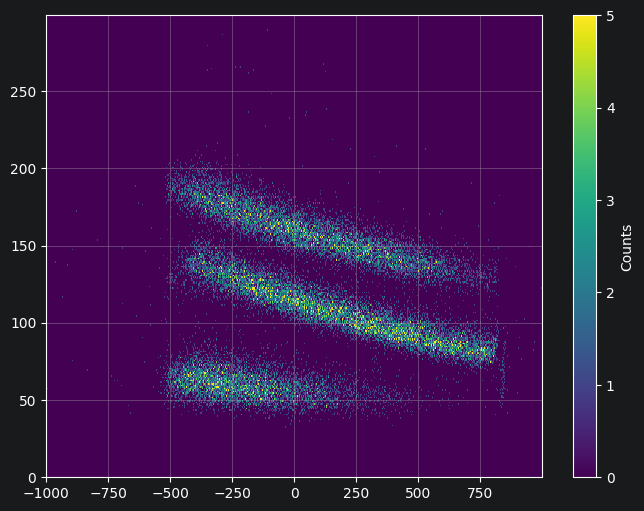

In [3]:
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
x_axis_variable=LASX
y_axis_variable=TOT
#hist range
x_axis_range_min = -1000
x_axis_range_max = 1000
y_axis_range_min = 0
y_axis_range_max = 300
#bin width
x_bin_width=1
y_bin_width=1
######################################################

# ヒストグラムを作成
bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
        np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins=bins)

# 図の準備
fig, ax = plt.subplots(figsize=(8, 6))
# ヒートマップの作成（カウントに応じて色付け）
norm = Normalize(vmin=0, vmax=np.max(hist) // 2)  # 色の範囲を細かく調整
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# カラーバーを追加
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Counts')

# 軸範囲とグリッド
# ax.set_xlabel('T_alpha[MeV]')
# ax.set_ylabel('Tp[MeV]')
ax.grid()

In [4]:
xdp=df['GRX']
adp=df['GRA']
ydp=df['GRY']
bdp=df['GRB']
GRQ2=df['GRQ2charge']

tracking_gated=df[
    (xdp!=-9999) & (ydp!=-9999)
]

xdp_track=tracking_gated['GRX']
adp_track=tracking_gated['GRA']
ydp_track=tracking_gated['GRY']
bdp_track=tracking_gated['GRB']
GRQ2_track=tracking_gated['GRQ2charge']

# proton_gated=tracking_gated[
#     (GRQ2_track>213.276-21.194*5) & (GRQ2_track<213.276+21.194*5)
# ]

# xdp_proton=proton_gated['GRX']
# adp_proton=proton_gated['GRA']
# ydp_proton=proton_gated['GRY']
# bdp_proton=proton_gated['GRB']
# GRQ2_proton=proton_gated['GRQ2charge']




# tested = df[
#     (GRQ2_track > 213.276-21.194*5) & (GRQ2_track < 213.276+21.194*5)
# ]

# #合わせる時は、GRQ2_trackとTOTを抽出してから
gated = df[
    (GRQ2_track>213.276-21.194*5) & (GRQ2_track<213.276+21.194*5) & (TOT+0.0430496*LASX-1.3842e-5*(LASX**2)>140) & (TOT+0.0430496*LASX-1.3842e-5*(LASX**2)<170)
]
GRQ2timing_gated = gated['GRQ2timing']
LASQ1timing_gated = gated['LASQ1timing']



In [5]:
gated

,run,iEve,GRX,GRA,GRY,GRB,GRQ2timing,GRQ2charge,LASX,LASA,LASY,LASB,LASQ1timing,LASTOT
2,2025,79,76.6026,0.007484,18.89030,-0.002013,146236.00,226.542,181.97800,0.077720,-206.6000,0.268428,146322.0,151.626
3,2025,85,254.6680,0.048382,-21.43400,0.005113,280165.00,202.365,153.15500,0.141902,38.8580,0.009935,280248.0,145.132
7,2025,242,441.3170,-0.010276,-7.12638,0.000953,21340.70,211.313,366.13200,0.018993,-43.2924,-0.020411,21075.1,140.714
11,2025,402,-34.5970,-0.031650,-12.32830,0.002291,6889.75,191.201,145.40100,0.008798,39.4162,0.015231,6977.1,148.355
13,2025,590,58.1263,0.012181,-11.62530,0.003453,178614.00,230.683,1.00431,0.176757,70.5937,0.038654,178640.0,149.979
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114479,2026,5946214,-129.0030,-0.028019,-17.97280,0.003862,429737.00,189.351,-311.79500,0.129594,14.0309,0.006555,430059.0,176.410
114483,2026,5946319,186.1630,0.010301,19.23750,-0.004590,219711.00,218.169,-351.13400,-0.177895,-28.1351,-0.000423,220164.0,181.005
114488,2026,5946355,-78.8341,0.011152,-30.96540,0.006082,316178.00,232.526,64.82520,0.045539,88.6055,0.057665,316260.0,154.524
114495,2026,5946580,-222.1470,-0.033318,-23.46050,0.003556,51493.10,234.663,213.61600,-0.066629,-15.4555,-0.013431,51403.9,151.377


Text(0, 0.5, 'counts')

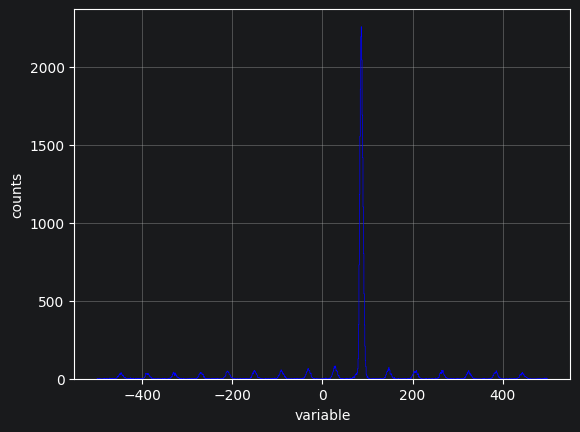

In [6]:
#TDiffのスペクトル
TDiff = LASQ1timing_gated - GRQ2timing_gated

#input
####################################################
#variables
variable=TDiff
#hist range
range_min=-500
range_max=500
#bin width
x_bin_width = 1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('variable')
ax.set_ylabel('counts')

Fitting parameters and their uncertainties:
Amp: 2199.499 ± 15.864
Mean: 86.469 ± 0.028
Sigma: 3.400 ± 0.028


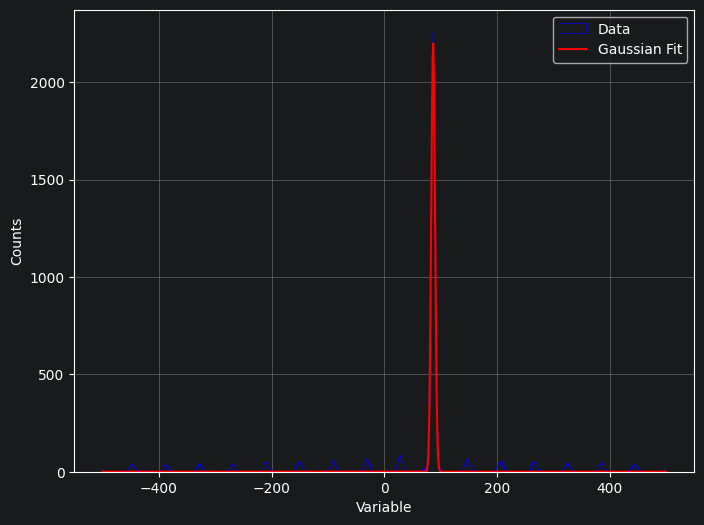

In [7]:
# Fitting
# Input
##############################################################
# Fitする変数
# variable = np.random.normal(loc=0, scale=10, size=1000)  # ダミーデータ
variable = TDiff
# Histogram range
hist_range_min = -500
hist_range_max = 500
# Bin width
bin_width = 1
# Fit range
fit_range_min = 0
fit_range_max = 200
# Initial parameters for the Gaussian
Amp = 2000
mean = 90
sigma = 5
# Fit parameter boundaries
bound_min = [0, fit_range_min, 0]
bound_max = [np.inf, fit_range_max, np.inf]
##############################################################
# ガウシアン関数の定義
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# データ範囲の選択
bins = np.arange(hist_range_min, hist_range_max + bin_width, bin_width)
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# フィット範囲を選択
mask = (bin_centers >= fit_range_min) & (bin_centers <= fit_range_max)
x_fit = bin_centers[mask]
y_fit = bin_counts[mask]

# 初期パラメータ
initial_guess = [Amp, mean, sigma]

# フィッティングを実行
popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=initial_guess, bounds=(bound_min, bound_max))

# フィット結果を取得
fit_y = gaussian(x_fit, *popt)

# 全てのフィッティングパラメータとその誤差を出力
print("Fitting parameters and their uncertainties:")
param_names = ["Amp", "Mean", "Sigma"]
for i, param in enumerate(popt):
    error = np.sqrt(pcov[i, i])
    print(f"{param_names[i]}: {param:.3f} ± {error:.3f}")

# フィット結果を描画
x_plot = np.linspace(hist_range_min, hist_range_max, 1000)
y_plot = gaussian(x_plot, *popt)

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(variable, bins=bins, histtype='step', color='blue', linewidth=0.5, label='Data')
ax.plot(x_plot, y_plot, color='red', linewidth=1.5, label='Gaussian Fit')
ax.grid()
ax.set_xlabel('Variable')
ax.set_ylabel('Counts')
ax.legend()

In [8]:
#true coincidenceのみ抽出
# mean = 84.98
# sigma = 17.718
mean = 86.947
sigma = 3.377

true = gated[
    (TDiff >= mean - 4 * sigma) & (TDiff <= mean + 4 * sigma)
]

GRQ2timing_true = true['GRQ2timing']
LASQ1timing_true = true['LASQ1timing']
TDiff_true = LASQ1timing_true - GRQ2timing_true

Text(0, 0.5, 'counts')

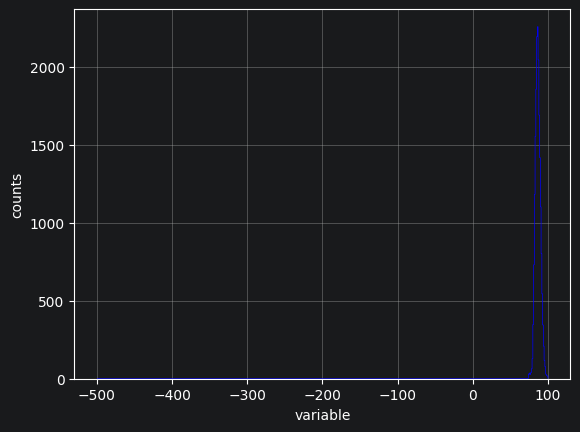

In [9]:
#input
####################################################
#variables
variable=TDiff_true
#hist range
range_min=-500
range_max=100
#bin width
x_bin_width = 1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('variable')
ax.set_ylabel('counts')

In [10]:
#　コインシデンスとったやつのみ抽出
GRX_true = true['GRX']
LASX_true = true['LASX']

#Tp, Tαを再構成

# Tp = []
# for n in GRX_gated:
#     Tp.append((((n * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27)

Tp = (((GRX_true * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27

# T_alpha = []
# for n in LASX_gated:
#     T_alpha.append(0.0274600000 * n + 63.8040000000)

T_alpha = 0.02746 * LASX_true + 63.804

Text(0, 0.5, 'counts')

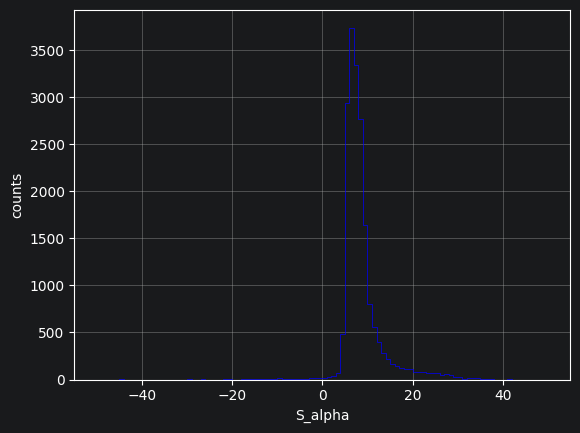

In [11]:
# リスト内包表記で各要素を足し算
S_alpha = [392 - (a + b) for a, b in zip(Tp, T_alpha)]

variables = S_alpha

#hist range
range_min=-50
range_max=50
#bin width
x_bin_width=1

####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅をx_bin_widthに設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variables, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variables, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('S_alpha')
ax.set_ylabel('counts')

Fitting parameters and their uncertainties:
Amp: 3780.494 ± 119.707
Mean: 7.189 ± 0.064
Sigma: 1.738 ± 0.064


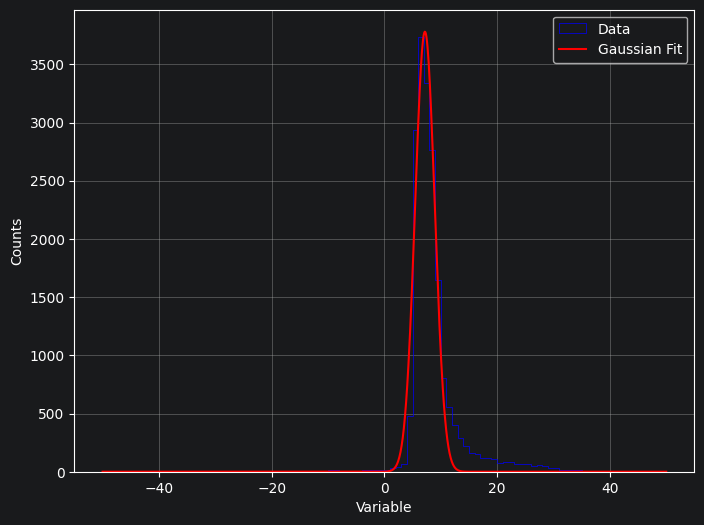

In [12]:
# Fitting
# Input
##############################################################
# Fitする変数
# variable = np.random.normal(loc=0, scale=10, size=1000)  # ダミーデータ
variable = S_alpha
# Histogram range
hist_range_min = -50
hist_range_max = 50
# Bin width
bin_width = 1
# Fit range
fit_range_min = -20
fit_range_max = 40
# Initial parameters for the Gaussian
Amp = 2500
mean = 10
sigma = 5
# Fit parameter boundaries
bound_min = [0, fit_range_min, 0]
bound_max = [np.inf, fit_range_max, np.inf]
##############################################################
# ガウシアン関数の定義
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# データ範囲の選択
bins = np.arange(hist_range_min, hist_range_max + bin_width, bin_width)
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# フィット範囲を選択
mask = (bin_centers >= fit_range_min) & (bin_centers <= fit_range_max)
x_fit = bin_centers[mask]
y_fit = bin_counts[mask]

# 初期パラメータ
initial_guess = [Amp, mean, sigma]

# フィッティングを実行
popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=initial_guess, bounds=(bound_min, bound_max))

# フィット結果を取得
fit_y = gaussian(x_fit, *popt)

# 全てのフィッティングパラメータとその誤差を出力
print("Fitting parameters and their uncertainties:")
param_names = ["Amp", "Mean", "Sigma"]
for i, param in enumerate(popt):
    error = np.sqrt(pcov[i, i])
    print(f"{param_names[i]}: {param:.3f} ± {error:.3f}")

# フィット結果を描画
x_plot = np.linspace(hist_range_min, hist_range_max, 1000)
y_plot = gaussian(x_plot, *popt)

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(variable, bins=bins, histtype='step', color='blue', linewidth=0.5, label='Data')
ax.plot(x_plot, y_plot, color='red', linewidth=1.5, label='Gaussian Fit')
ax.grid()
ax.set_xlabel('Variable')
ax.set_ylabel('Counts')
ax.legend()